<a href="https://colab.research.google.com/github/juacastanori/SyS/blob/main/GMDETECTOR2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#cargar datos desde drive acceso libre
FILEID = "18Nilf9-Sw0MWJeRZqRO5BHKtapIzZJin"

!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id='$FILEID -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id="$FILEID -O  basedatos.xlsx && rm -rf /tmp/cookies.txt
#!unzip -o codigos.zip
!dir

--2024-08-25 02:34:33--  https://docs.google.com/uc?export=download&confirm=&id=18Nilf9-Sw0MWJeRZqRO5BHKtapIzZJin
Resolving docs.google.com (docs.google.com)... 142.251.8.138, 142.251.8.113, 142.251.8.139, ...
Connecting to docs.google.com (docs.google.com)|142.251.8.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=18Nilf9-Sw0MWJeRZqRO5BHKtapIzZJin&export=download [following]
--2024-08-25 02:34:33--  https://drive.usercontent.google.com/download?id=18Nilf9-Sw0MWJeRZqRO5BHKtapIzZJin&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.187.132, 2404:6800:4008:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.187.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10184 (9.9K) [application/octet-stream]
Saving to: ‘basedatos.xlsx’

basedatos.xlsx      100%[===================>]   9.95K  --.-KB/s  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_ = 'basedatos.xlsx'#leer archivo xlsx con link, band, type
X  = pd.read_excel(file_)
X#imprimir filas iniciales

,link,band,type,type_num
0,https://www.youtube.com/watch?v=NQVgP1VJODc,franksinatra,jazz,1
1,https://www.youtube.com/watch?v=9n-hyA2-FDg,louisarmstrong,jazz,1
2,https://www.youtube.com/watch?v=ZEcqHA7dbwM,franksinatra,jazz,1
3,https://www.youtube.com/watch?v=uSiHqxgE2d0,raycharles,jazz,1
4,https://www.youtube.com/watch?v=ZZcuSBouhVA,milesdavis,jazz,1
5,https://www.youtube.com/watch?v=0WCzMju6yXQ,louisarmstrong,jazz,1
6,https://www.youtube.com/watch?v=6POZlJAZsok,billwhiters,jazz,1
7,https://www.youtube.com/watch?v=1Oe06936C0c,galtmacdermot,jazz,1
8,https://www.youtube.com/watch?v=vmDDOFXSgAs,davebrubeck,jazz,1
9,https://www.youtube.com/watch?v=Xv-E--ExbXU,ellafitzgerald,jazz,1


In [ ]:
#instalar librerias necesarias para descargar audios youtube
!python3 -m pip install --force-reinstall https://github.com/yt-dlp/yt-dlp/archive/master.tar.gz
!pip install soundfile

import os
import yt_dlp as youtube_dl

#funcion para descargar mp3 desde youtube
def download_ytvid_as_mp3(video_url,name):
    #video_url = input("enter url of youtube video:")
    video_info = youtube_dl.YoutubeDL().extract_info(url = video_url,download=False)
    filename = f"{name}.mp3"
    options={
        'format':'bestaudio/best',
        'keepvideo':False,
        'outtmpl':filename,
    }

    with youtube_dl.YoutubeDL(options) as ydl:
        ydl.download([video_info['webpage_url']])

    print("Download complete... {}".format(filename))

     - 2.7 MB 8.5 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached certifi-2024.7.4-py3-none-any.whl.metadata (2.2 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached charset_normalizer-3.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (33 kB)
Using cached requests-2.32.3-py3-none-any.whl (64 kB)
Using cached certifi-2024.7.4-py3-none-any.whl (162 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.4/121.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.2/157.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.1 MB/s eta 0:00:00
Using cached charset_normalizer-3.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinu

In [ ]:
import subprocess
import os

#crear carpeta con resultados
try:
  os.mkdir('results')
except:
  print("Carpeta results ya existe")

#recorrer excel con videos
N, P = X.shape
Ns = N * 5 #cantidad de segmentos por cancion

for n in range(N):
    print(f"video {n+1} de {N}")
    print(f"link: {X.loc[n,'link']}\n")
    print(f"band: {X.loc[n,'band']}\n")
    print(f"type: {X.loc[n,'type']}\n")
    #ruta video n-th
    name_ = 'results/'+X.loc[n,'band']+"_"+str(n)+"_"+str(X.loc[n,'type_num']) # #video+nombre+tipo de genero musical
    #descargar mp3 desde youtube
    download_ytvid_as_mp3(X.loc[n,'link'],name_)
    #convertir a .wav
    subprocess.call(['ffmpeg','-y', '-i', name_+'.mp3',
                   name_+'.wav'])

video 1 de 30
link: https://www.youtube.com/watch?v=NQVgP1VJODc

band: franksinatra

type: jazz

[youtube] Extracting URL: https://www.youtube.com/watch?v=NQVgP1VJODc
[youtube] NQVgP1VJODc: Downloading webpage
[youtube] NQVgP1VJODc: Downloading ios player API JSON
[youtube] NQVgP1VJODc: Downloading web creator player API JSON
[youtube] NQVgP1VJODc: Downloading player a87a9450
[youtube] NQVgP1VJODc: Downloading m3u8 information
[youtube] Extracting URL: https://www.youtube.com/watch?v=NQVgP1VJODc
[youtube] NQVgP1VJODc: Downloading webpage
[youtube] NQVgP1VJODc: Downloading ios player API JSON
[youtube] NQVgP1VJODc: Downloading web creator player API JSON
[youtube] NQVgP1VJODc: Downloading player a87a9450
[youtube] NQVgP1VJODc: Downloading m3u8 information
[info] NQVgP1VJODc: Downloading 1 format(s): 251
[download] Destination: results/franksinatra_0_1.mp3
[download] 100% of    2.50MiB in 00:00:00 at 11.24MiB/s  
Download complete... results/franksinatra_0_1.mp3
video 2 de 30
link: https

In [ ]:
#cargar .wavs y partir audios
#lista archivos .wav
path = 'results/'
wav_files = [f for f in os.listdir(path) if f.endswith('.wav')]
wav_files

['fisher_19_2.wav',
 'katyperry_27_3.wav',
 'louisarmstrong_5_1.wav',
 'martingarrix_15_2.wav',
 'dualipa_24_3.wav',
 'avicii_18_2.wav',
 'dualipa_25_3.wav',
 'arianagrande_20_3.wav',
 'skrillex_17_2.wav',
 'billwhiters_6_1.wav',
 'taylorswift_23_3.wav',
 'jasonderulo_26_3.wav',
 'ellafitzgerald_9_1.wav',
 'r3hab&kshmr_12_2.wav',
 'martingarrx_10_2.wav',
 'theweeknd_21_3.wav',
 'katyperry_28_3.wav',
 'davebrubeck_8_1.wav',
 'edsheeran_22_3.wav',
 'milesdavis_4_1.wav',
 'franksinatra_0_1.wav',
 'galtmacdermot_7_1.wav',
 'franksinatra_2_1.wav',
 'm83_11_2.wav',
 'britneyspears_29_3.wav',
 'raycharles_3_1.wav',
 'majorlazer_16_2.wav',
 'w&w_13_2.wav',
 'ummetozcan_14_2.wav',
 'louisarmstrong_1_1.wav']

In [ ]:
!pip install soundfile #instalar sondfile

In [ ]:
import soundfile as sf # para instalar pip install soundfile
#leer archivos y crear np.array audios
fs = 48000
tl = np.array([40,50,60,70,80,90,100]) #puntos lectura
ts = 5 #t segmento
Ns = len(wav_files)*len(tl) #cantidad segmentos
x_t = np.zeros((Ns,int(ts*fs),2)) #Ns segmentos, cantidad de muestras, 2 canales (stereo)
label = np.zeros((Ns,1)) #vector tipo de genero
name_c = []
#leer archivos wav
i = 0
for name in wav_files:#lectura audio .wav
    x, fs = sf.read(path+name)
    for ti in tl: #segmentos de tiempo
        x_t[i] = x[int(fs*ti):int(fs*(ti+ts)),:]
        label[i] = int(name[-5]) #tipo de genero
        name_c += [name[:-6]]
        print(f"{i} lectura: {name}; segundo {ti}:{ti+ts}; tipo música {label[i]}")
        i+=1
x_t.shape

0 lectura: fisher_19_2.wav; segundo 40:45; tipo música [2.]
1 lectura: fisher_19_2.wav; segundo 50:55; tipo música [2.]
2 lectura: fisher_19_2.wav; segundo 60:65; tipo música [2.]
3 lectura: fisher_19_2.wav; segundo 70:75; tipo música [2.]
4 lectura: fisher_19_2.wav; segundo 80:85; tipo música [2.]
5 lectura: fisher_19_2.wav; segundo 90:95; tipo música [2.]
6 lectura: fisher_19_2.wav; segundo 100:105; tipo música [2.]
7 lectura: katyperry_27_3.wav; segundo 40:45; tipo música [3.]
8 lectura: katyperry_27_3.wav; segundo 50:55; tipo música [3.]
9 lectura: katyperry_27_3.wav; segundo 60:65; tipo música [3.]
10 lectura: katyperry_27_3.wav; segundo 70:75; tipo música [3.]
11 lectura: katyperry_27_3.wav; segundo 80:85; tipo música [3.]
12 lectura: katyperry_27_3.wav; segundo 90:95; tipo música [3.]
13 lectura: katyperry_27_3.wav; segundo 100:105; tipo música [3.]
14 lectura: louisarmstrong_5_1.wav; segundo 40:45; tipo música [1.]
15 lectura: louisarmstrong_5_1.wav; segundo 50:55; tipo música 

(210, 240000, 2)

In [ ]:
from IPython.display import Audio #reproducir segmento
i = 10
Audio(x_t[i].T,rate=fs)

In [ ]:
#calculo de fourier
vf = np.fft.rfftfreq(x_t.shape[1],1/fs) #calculo vector de frecuencias
Xw = np.fft.rfft(x_t,axis=1).mean(axis=-1) #transformada rapida de Fourier para señal Real a lo largo del tiempo (axis=1) y se promedian los dos canales
Xw.shape

(210, 120001)

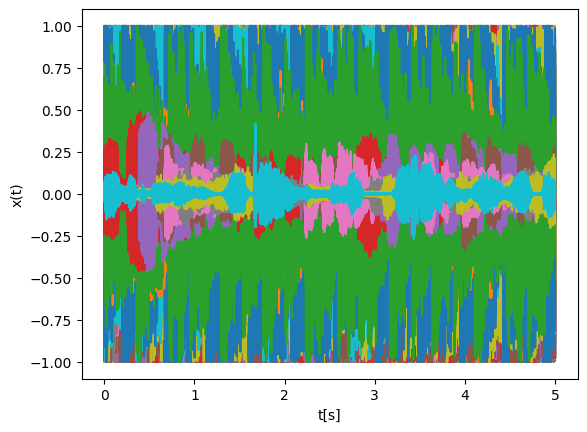

In [ ]:
#grafica tiempo y fourier
plt.plot(np.arange(0,ts,1/fs),x_t.mean(axis=-1).T) #se promedian los dos canales stereo
plt.xlabel('t[s]')
plt.ylabel('x(t)')
plt.show()

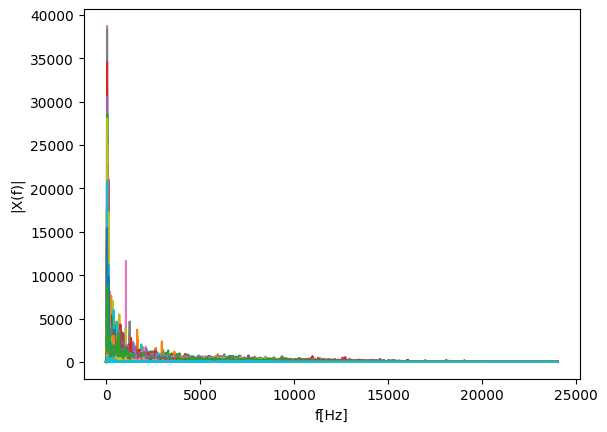

In [ ]:
plt.plot(vf,abs(Xw).T)
plt.xlabel('f[Hz]')
plt.ylabel('|X(f)|')
plt.show()

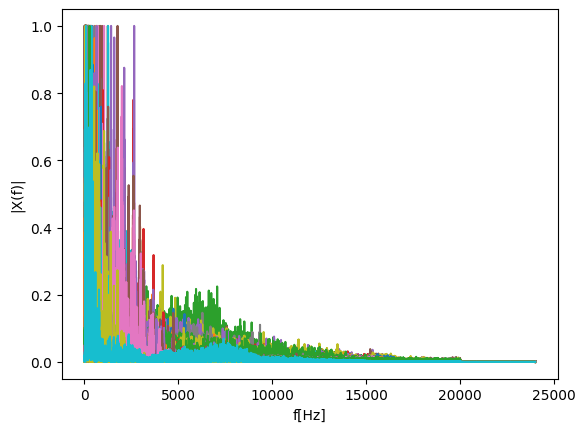

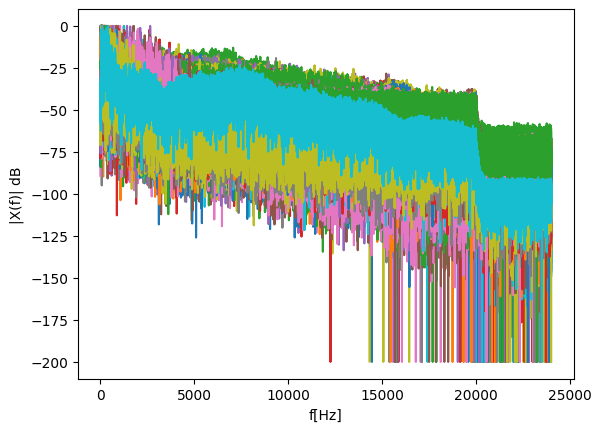

In [ ]:
#se normalizan espectros entre 0 y 1 para evitar inconsistencias por ampliltudes máximas
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler()
Xw_ = sca.fit_transform(abs(Xw).T).T

plt.plot(vf,Xw_.T)
plt.xlabel('f[Hz]')
plt.ylabel('|X(f)|')
plt.show()

#en dB
plt.plot(vf,(20*np.log10(Xw_+1e-10)).T) # se suma 1e-10 para evitar discontinuidad del log
plt.xlabel('f[Hz]')
plt.ylabel('|X(f)| dB')
plt.show()

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
#visualización de datos
red_ = TSNE(perplexity = 20,n_components=2,random_state=123,learning_rate='auto',init='pca')
#red_ = PCA(n_components=2,random_state=123)
fmax = 7000
X_2D = red_.fit_transform(Xw_[:,:fmax]) #se tiene en cuenta el espectro hasta fmax Hz

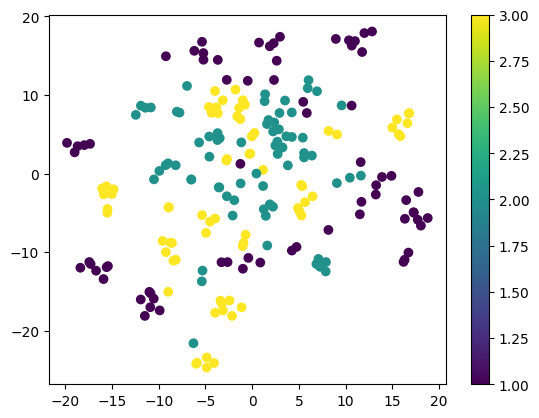

<ipython-input-14-a63ee7b6fab1>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(X_2D[i,0]*1.025,X_2D[i,1]*1.025, tex[:-2]+"_"+str(i), fontsize=6,color=color_[int(label[i]-1) % len(color_)])


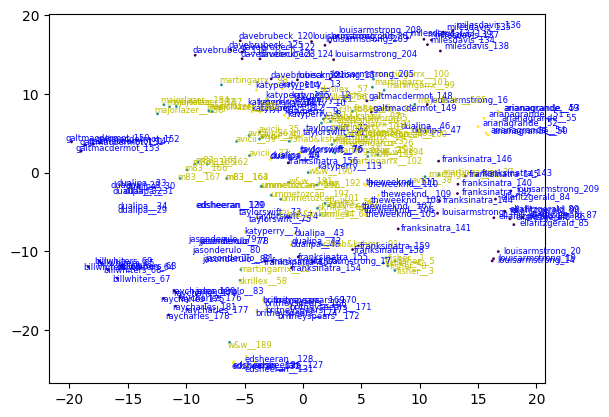

In [ ]:
#graficar separabilidad 2D
plt.scatter(X_2D[:,0],X_2D[:,1],c=label)
plt.colorbar()
plt.show()

color_ = ["b","y"]
#nombre cancion
plt.scatter(X_2D[:,0],X_2D[:,1],c=label,s=1)
for i, tex in enumerate(name_c):
    #print(f"{i} {tex}")
    # The following line ensures that the index is within the bounds of color_
    plt.text(X_2D[i,0]*1.025,X_2D[i,1]*1.025, tex[:-2]+"_"+str(i), fontsize=6,color=color_[int(label[i]-1) % len(color_)])

#plt.colorbar()
plt.show()


<ipython-input-15-267b8b35558e>:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_index = int(label[i]) - 1


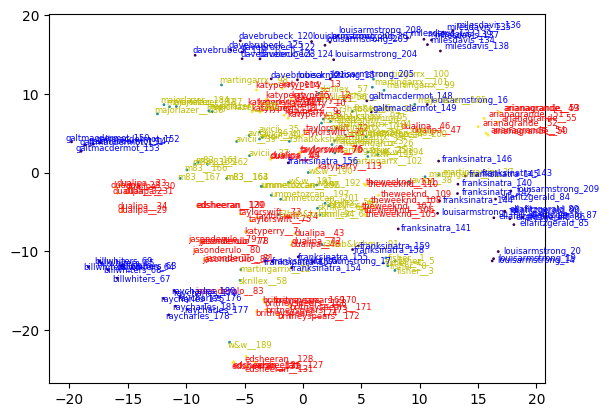

In [ ]:
plt.scatter(X_2D[:,0], X_2D[:,1], c=label, s=1)
colors=["b","y","r"]
for i, tex in enumerate(name_c):
    # Asegurar que el índice de la clase esté dentro del rango de colores
    class_index = int(label[i]) - 1
    if class_index >= len(colors) or class_index < 0:
        class_index = 0  # Asignar color por defecto si el índice está fuera de rango
    plt.text(X_2D[i,0]*1.025, X_2D[i,1]*1.025, tex[:-2]+"_"+str(i), fontsize=6, color=colors[class_index])

plt.show()

In [ ]:
import joblib
#guardar modelo
os.mkdir('modelo')
filename_ = 'modelo/jazz_vs_electronica_vs_pop'
model_ ={'Xw_':Xw_,'fmax': fmax, 'label' : label, 'name_c' : name_c, 'vf':vf,'fs':fs}
joblib.dump(model_,filename_+".pkl")

['modelo/jazz_vs_electronica_vs_pop.pkl']

In [ ]:
#descargar modelo
#guardar resultados
from google.colab import files
from datetime import date, datetime
import shutil
#guardar resultados
namefile = str(datetime.now().strftime("%Y_%m_%d_%H_%M_%d"))+'modelo'
shutil.make_archive(namefile, 'zip', 'modelo')
files.download(namefile+'.zip')

#el archivo .zip puede cargarse en drive y utilizarse en otro cuaderno para detectar género musical de nuevos segmentos

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#cargar modelo
my_model_loaded = joblib.load(filename_+".pkl")
my_model_loaded.keys()

dict_keys(['Xw_', 'fmax', 'label', 'name_c', 'vf', 'fs'])

In [ ]:
import numpy as np
import os
import joblib
import soundfile as sf
import subprocess
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import euclidean

# Cargar el modelo guardado
filename_ = '/content/modelo/jazz_vs_electronica_vs_pop.pkl'
my_model_loaded = joblib.load(filename_)

Xw_ = my_model_loaded['Xw_']
fmax = my_model_loaded['fmax']
label = my_model_loaded['label']
name_c = my_model_loaded['name_c']
vf = my_model_loaded['vf']
fs = my_model_loaded['fs']

def process_audio(filename, tl=[40,50,60,70,80,90,100], ts=5):
    # Convertir a .wav
    subprocess.call(['ffmpeg', '-y', '-i', filename + '.mp3', filename + '.wav'])
    x, fs = sf.read(filename + '.wav')

    segments = []
    for ti in tl:  # Segmentos de tiempo
        segment = x[int(fs*ti):int(fs*(ti+ts)), :]
        segments.append(segment)

    return np.array(segments)

def compute_fft_normalize(segments):
    Xw_new = np.fft.rfft(segments, axis=1).mean(axis=-1)
    sca = MinMaxScaler()
    Xw_new_ = sca.fit_transform(abs(Xw_new).T).T
    return Xw_new_

def classify_genre(Xw_new_, Xw_, label, fmax):
    distances = []
    for i in range(Xw_new_.shape[0]):
        min_dist = float('inf')
        min_label = None

        for j in range(Xw_.shape[0]):
            # Calcular la distancia euclidiana
            dist = euclidean(Xw_new_[i, :fmax], Xw_[j, :fmax])
            if dist < min_dist:
                min_dist = dist
                min_label = label[j]

        distances.append((min_dist, min_label))

    # Tomar el género más frecuente entre los segmentos
    predicted_genre = max(distances, key=lambda x: distances.count(x))[1]

    return predicted_genre

# Ejemplo de uso
new_song_url = input("Ingrese el link: ")
new_song_name = input("\nIngrese el nombre de la cancion: ")

# Descargar y procesar la nueva canción
download_ytvid_as_mp3(new_song_url, new_song_name)
segments = process_audio(new_song_name)
Xw_new_ = compute_fft_normalize(segments)

# Clasificar la canción
predicted_genre = classify_genre(Xw_new_, Xw_, label, fmax)
genre_dict = {1: "Jazz", 2: "Electronica", 3: "Pop"}

print(f"La canción nueva es clasificada como: {genre_dict[int(predicted_genre)]}")


Ingrese el link: https://www.youtube.com/watch?v=CcCw1ggftuQ

Ingrese el nombre de la cancion: round
[youtube] Extracting URL: https://www.youtube.com/watch?v=CcCw1ggftuQ
[youtube] CcCw1ggftuQ: Downloading webpage
[youtube] CcCw1ggftuQ: Downloading ios player API JSON
[youtube] CcCw1ggftuQ: Downloading web creator player API JSON
[youtube] CcCw1ggftuQ: Downloading m3u8 information
[youtube] Extracting URL: https://www.youtube.com/watch?v=CcCw1ggftuQ
[youtube] CcCw1ggftuQ: Downloading webpage
[youtube] CcCw1ggftuQ: Downloading ios player API JSON
[youtube] CcCw1ggftuQ: Downloading web creator player API JSON
[youtube] CcCw1ggftuQ: Downloading m3u8 information
[info] CcCw1ggftuQ: Downloading 1 format(s): 251
[download] Destination: round.mp3
[download] 100% of    3.09MiB in 00:00:00 at 10.41MiB/s  
Download complete... round.mp3
La canción nueva es clasificada como: Pop


<ipython-input-34-82178bb24ab3>:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"La canción nueva es clasificada como: {genre_dict[int(predicted_genre)]}")
